# 实验：VOC数据集转YOLO格式并调用YOLOv8n训练

## 实验目标
1. 将VOC格式的摩托车数据集自动转换为YOLO格式（含自动划分训练集/验证集）。
2. 调用Ultralytics YOLOv8n预训练模型进行单类目标检测（motorbike）。
3. 掌握YOLOv8的训练流程、验证指标解读及推理可视化。
4. 对比理解Anchor-Free检测器（YOLOv8）与YOLOv1在工程实现上的差异。

## 实验环境
- Python &gt;= 3.8
- PyTorch &gt;= 1.10
- ultralytics &gt;= 8.0
- PIL, matplotlib, numpy, tqdm

In [1]:
import os
import shutil  #shutil全称为shell utility，是python内置标准库，比os功能更加强大，能实现文件/文件夹的复制、移动、删除等高级操作
import random
import xml.etree.ElementTree as ET
"""
此处说明一下有关XML的知识，XML全称为Extensible Markup Language，意为“可扩展标记语言”，属于标记语言，不属于编程语言
熟悉前端或者全栈开发的都知道HTML（HyperText Markup Language），即“超文本标记语言”，它同样是一种标记语言而不是一种编程语言
在HTML中，我们使用各种各样的“标签”，通过各种方式组合在浏览器给用户呈现出不同的效果
标签分单标签和双标签，单标签单独生效，双标签成对生效，但是在HTML中标签固定预设，而在XML中标签名则是自定义的，但是两者的标签间逻辑关系都是树形
将每个标签抽象为结点node，根据数据结构的知识，如果一个标签a在标签b内部，我们可以认为node a是node b的孩子，node b是node a的父节点，
如果标签a和标签c并列（二者之间无缩进），我们可以认为node a是node c的兄弟节点，当然这棵标签树不一定是二叉树，叉数是任意的，甚至可以是一个链表

更进一步，根据OOP面向对象思想，我们可以认为整个XML文件作为一棵元素树也是一个对象（而且是内置对象），而这个内置对象就是ElementTree，
同样HTML文件作为一棵元素树也是一个内置对象，就是Document（熟悉JavaScript的肯定知道）

这就是xml.etree.ElementTree名字的由来，etree就是element tree的简写
"""
from pathlib import Path  #用来处理文件/文件夹路径相关问题，os.path同样也能实现

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches  #用来实现绘制诸如矩形、椭圆、圆形、箭头、多边形等图像
from PIL import Image
from tqdm import tqdm  #用来加载任务进度，以进度条的形式呈现

# Jupyter 内联显示图像（必须放在导入 pyplot 之后）
%matplotlib inline

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_str = '0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device} | YOLO device string: {device_str}")

Using device: cpu | YOLO device string: cpu


## 1. VOC格式转YOLO格式

### 转换原因
Ultralytics YOLOv8要求数据集为YOLO格式，每张图像对应一个同名的.txt标签文件。

### YOLO标签格式
每行代表一个目标，共5个数值（空格分隔）：class_id  x_center  y_center  width  height

所有坐标均为相对于图像宽高的**归一化值**（范围 0~1）。

### 转换后目录结构
```
tiny_motorbike_yolo/
├── data.yaml
├── images/
│   ├── train/
│   └── val/
└── labels/
    ├── train/
    └── val/
```


### 自动划分
由于原始数据集未提供train/val列表，脚本将按split_ratio（默认0.8）自动随机划分，并同步复制图像与生成标签。

In [2]:
import os
import random
import shutil
from pathlib import Path
from tqdm import tqdm
import xml.etree.ElementTree as ET

def convert_voc_to_yolo(voc_root, output_root, split_ratio=0.8, seed=42):
    """
    将VOC格式数据集转换为YOLO格式，并自动划分train/val
    仅保留类别名中包含'motor'的目标（motorbike / motorcycle），class_id=0
    """
    voc_root = Path(voc_root)  #将一个字符串传入Path中返回一个Path路径对象，而不是一个String，其可以通过'/''\'来实现自动拼接
    img_dir = voc_root / 'JPEGImages'
    ann_dir = voc_root / 'Annotations'  #annotation就是“注释”的意思，Annotations里存放的都是XML文件
    
    out_root = Path(output_root)
    for split in ['train', 'val']:
        (out_root / 'images' / split).mkdir(parents=True, exist_ok=True)
        (out_root / 'labels' / split).mkdir(parents=True, exist_ok=True)
    """
    上述mkdir中的两个参数体现了Path的强大，特别的，out_root/'images'/split是一个Path路径对象，mkdir是Path路径对象的一个方法
    举个例子，我们现在要创建out_root/'images'/'train'，而此时只有out_root而不是out_root/'images'，如果不加parents=True则会报错，
    因为系统找不到train的父级目录images，而设置parents=True则不会报错，并会帮我们自动创建images和train

    同样当我们创建好了out_root/'images'/'train'之后，如果我们又跑了一遍代码，不加exist_ok=True则会报错，因为系统发现已创建，
    加上exist_ok=True则系统会自动忽略
    """
    
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    all_items = []
    for fname in sorted(os.listdir(img_dir)):
        name, ext = os.path.splitext(fname)  #os.path.splitext()可以将文件名和文件后缀分开，文件名用name接收，后缀用ext（extension，扩展名）来接收
        if ext.lower() in valid_exts:
            all_items.append((name, ext.lower()))  #all_items中的每个元素都是一个二元组：（文件名，文件后缀）
    
    if len(all_items) == 0:
        raise ValueError(f"未在 {img_dir} 找到有效图像！")
    
    random.seed(seed)
    random.shuffle(all_items)
    n_train = int(len(all_items) * split_ratio)
    train_items = all_items[:n_train]
    val_items = all_items[n_train:]
    
    def process(items, split):  #process是真正用来将VOC格式转换为YOLO格式的函数，其中items是要处理的图片列表，split是train or val
        for name, ext in tqdm(items, desc=f"Convert {split}"):  #第二个参数desc即description的简写，可以在进度条前打印作为描述
            img_src = img_dir / f"{name}{ext}"
            img_dst = out_root / 'images' / split / f"{name}{ext}"
            shutil.copy(img_src, img_dst)  #将文件从源路径img_src复制到目标路径img_dst
            
            ann_path = ann_dir / f"{name}.xml"
            if not ann_path.exists():  #特别的，YOLO模型要求每张图片必须要有一个对应的txt文件，就算没有对应标注Annotation也要有一个空的txt，否则会报错
                lbl_dst = out_root / 'labels' / split / f"{name}.txt"
                open(lbl_dst, 'w').close()  #特别的，lbl_dst = out_root / 'labels' / split / f"{name}.txt"只是创建了一个Path路径对象，没有创建真实的txt文件
                continue                    #我们可以使用open()+write来创建，由于是空txt所以我们不必写具体的内容，直接.close()关闭即可，否则会占用内存
            
            tree = ET.parse(ann_path)  #打开并解析这个XML文件，加载到内存中变为一棵文档树（Document Tree）
            root = tree.getroot()  #获取根节点，即最外层标签<annotation>
            size = root.find('size')  #获取子标签<size>
            W = int(size.find('width').text)  #获取<size>子标签<width>包裹的值，注意要转为int类型
            H = int(size.find('height').text)  #同理
            
            lines = []
            for obj in root.findall('object'):  #观察每个XML文件结构可知，每个<annotation>标签含有多个<object>子标签，就是说一张图片里有多个对象
                                                #root.findall('object')会返回一个以所有<object>标签为元素的数组
                #获取类别名，只保留包含 motor 的（motorbike/motorcycle）
                cls_name = obj.find('name').text.strip().lower()  #cls_name为每个<object>标签中<name>子标签包裹的内容
                if 'motor' not in cls_name:
                    continue  #如果不是摩托车则跳过
                
                #读取 VOC 标注框：xmin, ymin, xmax, ymax
                bndbox = obj.find('bndbox')  #同理
                xmin = float(bndbox.find('xmin').text)
                ymin = float(bndbox.find('ymin').text)
                xmax = float(bndbox.find('xmax').text)
                ymax = float(bndbox.find('ymax').text)
                
                #VOC → YOLO 公式计算
                bw = xmax - xmin  # 框的实际宽度
                bh = ymax - ymin  # 框的实际高度
                
                #中心点坐标（归一化）
                cx = (xmin + xmax) / (2 * W)
                cy = (ymin + ymax) / (2 * H)
                
                #宽高归一化
                w = bw / W
                h = bh / H
                
                #写入 YOLO 格式，我们认为摩托车的类为0
                lines.append(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
            
            # 写入标签文件
            lbl_dst = out_root / 'labels' / split / f"{name}.txt"
            with open(lbl_dst, 'w') as f:
                f.write('\n'.join(lines))
    
    process(train_items, 'train')  #调用process函数
    process(val_items, 'val')
    
    print(f"\n转换完成：Train={len(train_items)}, Val={len(val_items)}")
    return out_root


# 执行转换
DATA_VOC = './tiny_motorbike'
DATA_YOLO = './tiny_motorbike_yolo'

convert_voc_to_yolo(DATA_VOC, DATA_YOLO, split_ratio=0.8)

Convert val: 100%|████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 157.21it/s]


转换完成：Train=176, Val=44


WindowsPath('tiny_motorbike_yolo')

In [3]:
# 创建 data.yaml 配置文件
yaml_path = Path(DATA_YOLO) / 'data.yaml'

#.resolve()用于输出绝对路径
yaml_content = f"""
path: {Path(DATA_YOLO).resolve()}
train: images/train 
val: images/val
nc: 1
names:
  0: motorbike
"""

#特别的，在yaml_content中，path为数据集根目录，train为训练集图片路径，val为验证集图片路径,nc（number of classes）为类的数量，names为第i类对应的名字

with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write(yaml_content.strip())

print(f"data.yaml 已创建：{yaml_path.resolve()}")
print(yaml_content)

data.yaml 已创建：D:\2026_Spring\Experiment_09\tiny_motorbike_yolo\data.yaml

path: D:\2026_Spring\Experiment_09\tiny_motorbike_yolo
train: images/train 
val: images/val
nc: 1
names:
  0: motorbike



## 2. YOLOv8n 模型说明

### 为什么选择YOLOv8n？
- **n** 代表 nano，是YOLOv8系列最轻量的模型，参数量仅约 3.2M，适合课堂快速训练与演示。
- 基于C2f模块和Anchor-Free设计，无需手动设置Anchor。
- 在MS COCO上预训练，具备强大的通用目标特征提取能力。

### 训练策略
- **迁移学习**：加载COCO预训练的 yolov8n.pt，Backbone权重冻结若干epoch或直接全模型微调。
- **输入尺寸**：默认 640×640，YOLOv8会自动进行Mosaic增强、MixUp、随机翻转等数据增强。
- **损失函数**：由CIoU Loss（定位）、DFL（Distribution Focal Loss，回归分支）和BCE Loss（分类）组成，无需手动实现。

In [4]:
from ultralytics import YOLO

# 加载预训练模型（首次运行会自动下载 yolov8n.pt 到当前目录）
model = YOLO('yolov8n.pt')

# 查看模型信息
print(f"模型类别数（COCO）: {len(model.names)}")
print(f"模型将自动适配为单类检测（data.yaml中names只有1个）")

模型类别数（COCO）: 80
模型将自动适配为单类检测（data.yaml中names只有1个）


## 3. 训练配置

| 超参数 | 取值 | 说明 |
|---|---|---|
| 模型 | yolov8n.pt | COCO预训练，单类微调 |
| Epoch | 50 | YOLOv8收敛极快，通常30~50 epoch足够 |
| imgsz | 640 | 输入尺寸，YOLOv8会自动Resize与填充 |
| batch | 8 | 根据显存调整 |
| patience | 10 | 早停：若10个epoch无提升则停止 |
| device | 0 / cpu | GPU或CPU |
| 数据增强 | 内置 | Mosaic、MixUp、随机翻转、HSV抖动等 |

### 关键提示
- 无需手动编写损失函数、解码器或NMS，ultralytics已内置。
- 训练过程会自动保存最优权重到 `runs/detect/train/weights/best.pt`。

In [5]:
# 开始训练
# 注意：如果显存不足，可将 batch 降为 4，imgsz 降为 416
# 阅读 https://docs.ultralytics.com/models/yolov8
results = model.train(
    data="./tiny_motorbike_yolo/data.yaml",  
    epochs=15,                              
    imgsz=416,                              
    batch=4,                                 
    name="motorbike_yolov8n"  #此时系统会默认将所有训练结果存储到：项目根目录/runs/detect/motorbike_yolov8n/下              
)

print("训练完成！")
BEST_PT = results.save_dir / "weights" / "best.pt"  #results.save_dir会输出model.train()中你设置的name值的绝对路径
print(f"最优权重路径: {BEST_PT}")

New https://pypi.org/project/ultralytics/8.4.52 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.48  Python-3.9.25 torch-2.5.1 CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./tiny_motorbike_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mot

## 4. 验证集评估

训练完成后，使用验证集计算标准COCO指标：

- **mAP50**：IoU=0.5时的平均精度均值（主要关注指标）
- **mAP50-95**：IoU从0.5到0.95步进0.05的平均mAP（更严格的定位评估）
- **Precision (P)**：查准率，预测为摩托车的框中真正是摩托车的比例
- **Recall (R)**：查全率，所有真实摩托车中被检出的比例

YOLOv8的val()会自动执行NMS并计算上述指标。

In [6]:
# 加载训练后的最优权重进行验证
best_model = YOLO(BEST_PT)

# 在验证集上评估
metrics = best_model.val(
    data="./tiny_motorbike_yolo/data.yaml",  
    split="val",                             # 验证集
    imgsz=416                                # 图片尺寸
)

# 打印指标
print("=" * 50)
print("Validation Results (COCO Metrics)")
print(f"  mAP50        : {metrics.box.map50:.4f}")
print(f"  mAP50-95     : {metrics.box.map:.4f}")
print(f"  Precision    : {metrics.box.mp:.4f}")
print(f"  Recall       : {metrics.box.mr:.4f}")
print("=" * 50)

Ultralytics 8.4.48  Python-3.9.25 torch-2.5.1 CPU (12th Gen Intel Core i7-12700H)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.30.2 ms, read: 252.9103.4 MB/s, size: 93.6 KB)
val: Scanning D:\2026_Spring\Experiment_09\tiny_motorbike_yolo\labels\val.cache... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.5s1.6s
                   all         44         66      0.873      0.726      0.834      0.532
Speed: 0.5ms preprocess, 37.8ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to D:\2026_Spring\Experiment_09\runs\detect\val-4
Validation Results (COCO Metrics)
  mAP50        : 0.8338
  mAP50-95     : 0.5324
  Precision    : 0.8725
  Recall       : 0.7259


## 5. 测试推理与可视化

### 单张图像推理
使用训练好的模型对验证集图像进行预测，可视化检测框与置信度。

### 批量对比
随机抽取3张验证集图像，左侧显示Ground Truth（红色），右侧显示YOLOv8预测结果（绿色），直观对比定位精度。

===== 单张图像推理结果 =====


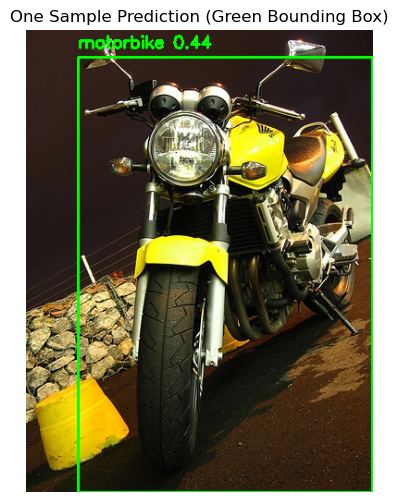


===== 随机3张验证集 真实框VS预测框对比 =====


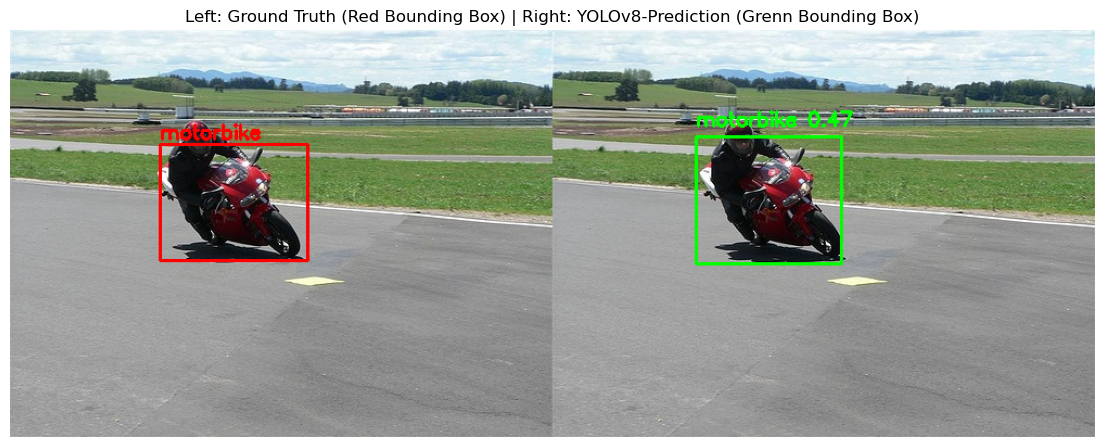

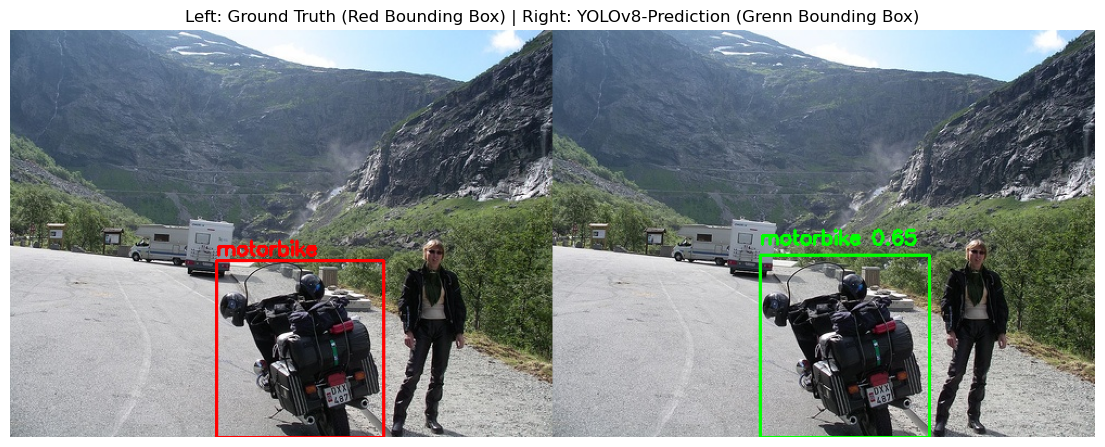

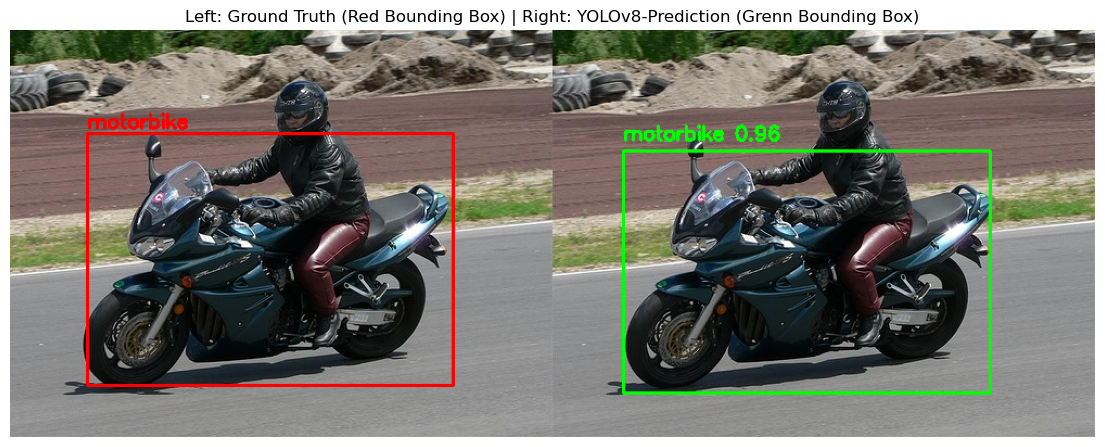

In [12]:
import random
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt


# 路径配置
DATA_YOLO = "./tiny_motorbike_yolo"
VAL_IMAGES_DIR = Path(DATA_YOLO) / "images" / "val"
VAL_LABELS_DIR = Path(DATA_YOLO) / "labels" / "val"

# 加载训练好的最优模型（沿用你前面定义的 BEST_PT）
model = YOLO(BEST_PT)

CLASS_NAMES = ['motorbike']
COLOR_GT    = (0, 0, 255)    # 红色 真实框
COLOR_PRED  = (0, 255, 0)    # 绿色 预测框

# 工具：解析YOLO标签txt，转像素框
def load_yolo_boxes(txt_path, img_w, img_h):
    boxes = []
    if not txt_path.exists():  #注意一张图片中可能一个真实框都没有
        return boxes
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f.readlines():
            line = line.strip()
            if not line:  
                continue
            cid, cx, cy, bw, bh = map(float, line.split())  #相对坐标转换为绝对坐标
            x1 = int((cx - bw/2) * img_w)
            y1 = int((cy - bh/2) * img_h)
            x2 = int((cx + bw/2) * img_w)
            y2 = int((cy + bh/2) * img_h)
            boxes.append([int(cid), x1, y1, x2, y2])
    return boxes

# 工具：画图框
def draw_box(img, boxes, color):
    img = img.copy()
    for cid, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img, CLASS_NAMES[cid], (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

# ===================== 1. 单张图像推理可视化（绿色框） =====================
print("===== 单张图像推理结果 =====")
img_list = [
    f for f in VAL_IMAGES_DIR.iterdir()
    if f.suffix.lower() in ['.jpg', '.jpeg', '.png']  #特别的，使用.iterdir()读取出来的元素仍是Path路径对象，其没有.endwith()方法，但是有.suffix属性，效果一样
]
sample_img = random.choice(img_list)  #random.choice()可以随机选取一个元素

# 读取原图
img = cv2.imread(str(sample_img))  #特别的，sample_img是一个Path路径对象，我们要将其强转为str类型才能用于读取图片
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  #开发者最初设置imread读取图像后，通道默认为BGR，但是后续matplotlib使用的是RGB，因此我们要转换一下顺序

# 模型预测
res = model.predict(str(sample_img), conf=0.25, verbose=False)[0]  #conf即置信度confidence的简写，我们这里只显示置信度≥25%的预测框，verbose=False用于关闭冗余的打印日志
                                                                   #特别的，由于model.predict()支持上传多张图片，因此返回的是一个数组，即便你只上传一张图片它也会返回一个数组，这里我们上传一张照片，因此要在后面加上[0]
# 手动绘制绿色预测框
img_pred = img.copy()  #后续随机3张验证集照片可能会用到此处的照片，所以我们需要拷贝一下，否则验证框将会画在原图上，可能会影响后续预测结果
for box in res.boxes:  #遍历模型预测出来的所有框（因为可能不止一个）
    x1, y1, x2, y2 = map(int, box.xyxy[0])  #取出预测框的坐标信息
    conf = box.conf[0]  #取出预测框的置信度
    cv2.rectangle(img_pred, (x1, y1), (x2, y2), COLOR_PRED, 2)  #画出预测框，注意OpenCV相关的操作都是在BGR图片上进行的
    cv2.putText(img_pred, f"motorbike {conf:.2f}",  #添加标题和置信度信息
                (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_PRED, 2)

# 显示，此时才用RGB图片
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB))
plt.axis("off")  #我们此时用不到坐标轴、刻度数字等，所以关掉
plt.title("One Sample Prediction (Green Bounding Box)")
plt.show()

print("\n===== 随机3张验证集 真实框VS预测框对比 =====")
sample_3 = random.sample(img_list, 3)

for img_path in sample_3:
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    
    # 1. 读取真实标签 画红框
    label_path = VAL_LABELS_DIR / (img_path.stem + ".txt")
    gt_boxes = load_yolo_boxes(label_path, w, h)
    img_gt = draw_box(img, gt_boxes, COLOR_GT)
    
    res = model.predict(str(img_path), conf=0.25, verbose=False)[0]
    img_pred_custom = img.copy()
    for box in res.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = box.conf[0]  # 取出置信度
        cv2.rectangle(img_pred_custom, (x1, y1), (x2, y2), COLOR_PRED, 2)
        cv2.putText(img_pred_custom, f"motorbike {conf:.2f}",  # 这里加上置信度
                (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_PRED, 2)
    
    #将含有真实框的图片和含有预测框的图片左右拼接在一起
    combine = np.hstack([img_gt, img_pred_custom])
    
    plt.figure(figsize=(14,6))
    plt.imshow(cv2.cvtColor(combine, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Left: Ground Truth (Red Bounding Box) | Right: YOLOv8-Prediction (Grenn Bounding Box)")
    plt.show()

## 6. 实验总结与对比

### 核心要点
1. **格式转换**：VOC的XML需转为YOLO的txt（归一化中心坐标+宽高），并同步划分train/val。
2. **YOLOv8优势**：无需手写Backbone、损失函数或NMS，ultralytics框架已高度封装，训练效率远高于手写YOLOv1。
3. **预训练威力**：YOLOv8n在COCO上预训练，单类微调时通常10~20个epoch即可达到mAP50 &gt; 0.7。

### YOLOv1 vs YOLOv8 工程差异
| 维度 | 手写YOLOv1 | YOLOv8 (ultralytics) |
|---|---|---|
| Backbone | 手动搭建浅层CNN | 预训练CSPDarknet |
| Anchor | 手动设定 | Anchor-Free |
| 损失函数 | 手写MSE+权重 | 内置CIoU+DFL+BCE |
| 数据增强 | 需自行实现 | 内置Mosaic、MixUp等 |
| NMS | 手写 | 内置 |
| 部署 | 需自行导出 | 一键导出ONNX/TensorRT/CoreML |

